In [138]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [166]:
pd.set_option("display.max.rows", 700)

In [230]:
df = pd.read_excel(r"C:\Users\User\Downloads\Table_1.1_Primary_Energy_Overview.xlsx", header= 10)
df.head(500)

,Month,Total Fossil Fuels Production,Nuclear Electric Power Production,Total Renewable Energy Production,Total Primary Energy Production,Primary Energy Imports,Primary Energy Exports,Primary Energy Net Imports,Primary Energy Stock Change and Other,Total Fossil Fuels Consumption,Nuclear Electric Power Consumption,Total Renewable Energy Consumption,Total Primary Energy Consumption
0,NaT,(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu),(Quadrillion Btu)
1,1973-01-01,4.932632,0.068103,0.219839,5.220574,1.17308,0.125781,1.047299,0.771858,6.747651,0.068103,0.219839,7.039731
2,1973-02-01,4.729582,0.064634,0.19733,4.991545,1.168005,0.120883,1.047122,0.390129,6.163095,0.064634,0.19733,6.428796
3,1973-03-01,4.946902,0.072494,0.218686,5.238082,1.309473,0.13995,1.169523,-0.06764,6.044647,0.072494,0.218686,6.339964
4,1973-04-01,4.716271,0.06407,0.20933,4.989672,1.085169,0.194185,0.890984,-0.110067,5.493184,0.06407,0.20933,5.770589
5,1973-05-01,4.956995,0.062111,0.215982,5.235087,1.162804,0.196775,0.966029,-0.305335,5.613551,0.062111,0.215982,5.895781
6,1973-06-01,4.716096,0.073968,0.208249,4.998313,1.129614,0.178871,0.950743,-0.315356,5.347479,0.073968,0.208249,5.6337
7,1973-07-01,4.748276,0.07589,0.2078,5.031966,1.216246,0.164134,1.052112,-0.291695,5.504556,0.07589,0.2078,5.792383
8,1973-08-01,5.041997,0.084883,0.203432,5.330313,1.297848,0.191049,1.106799,-0.39578,5.748879,0.084883,0.203432,6.041332
9,1973-09-01,4.731504,0.085724,0.1853,5.002528,1.226145,0.146492,1.079652,-0.430371,5.376782,0.085724,0.1853,5.651809


In [231]:
# filter to view data from 2020 - 2024
df =df[df["Month"] >= "2020-01-01"]

In [234]:
# select just the columns needed 
df = df[["Month", "Total Primary Energy Production", "Total Primary Energy Consumption", "Primary Energy Imports", "Primary Energy Exports", "Primary Energy Stock Change and Other"]]

In [236]:
df.head(500)

,Month,Total Primary Energy Production,Total Primary Energy Consumption,Primary Energy Imports,Primary Energy Exports,Primary Energy Stock Change and Other
565,2020-01-01,8.51254,8.651425,1.871493,2.175213,0.442605
566,2020-02-01,7.787214,8.021148,1.72719,2.088791,0.595535
567,2020-03-01,8.135691,7.537447,1.782154,2.236072,-0.144326
568,2020-04-01,7.487145,6.163349,1.507487,1.879794,-0.951489
569,2020-05-01,7.101509,6.433366,1.651252,1.693721,-0.625674
570,2020-06-01,7.285709,6.8834,1.704521,1.658983,-0.447847
571,2020-07-01,7.665998,7.71247,1.69169,1.874128,0.22891
572,2020-08-01,7.658697,7.685118,1.612727,1.877792,0.291486
573,2020-09-01,7.451752,7.008373,1.544957,1.852767,-0.13557
574,2020-10-01,7.452189,7.157795,1.578486,1.975293,0.102413


In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 565 to 622
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Month                                  58 non-null     datetime64[ns]
 1   Total Primary Energy Production        58 non-null     object        
 2   Total Primary Energy Consumption       58 non-null     object        
 3   Primary Energy Imports                 58 non-null     object        
 4   Primary Energy Exports                 58 non-null     object        
 5   Primary Energy Stock Change and Other  58 non-null     object        
dtypes: datetime64[ns](1), object(5)
memory usage: 3.2+ KB


In [240]:
# convert all the columns except date column to floats 
df[["Total Primary Energy Production", "Total Primary Energy Consumption", "Primary Energy Imports", "Primary Energy Exports", "Primary Energy Stock Change and Other"]] = df[["Total Primary Energy Production", "Total Primary Energy Consumption", "Primary Energy Imports", "Primary Energy Exports", "Primary Energy Stock Change and Other"]].astype(float)

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 565 to 622
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Month                                  58 non-null     datetime64[ns]
 1   Total Primary Energy Production        58 non-null     float64       
 2   Total Primary Energy Consumption       58 non-null     float64       
 3   Primary Energy Imports                 58 non-null     float64       
 4   Primary Energy Exports                 58 non-null     float64       
 5   Primary Energy Stock Change and Other  58 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 3.2 KB


C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


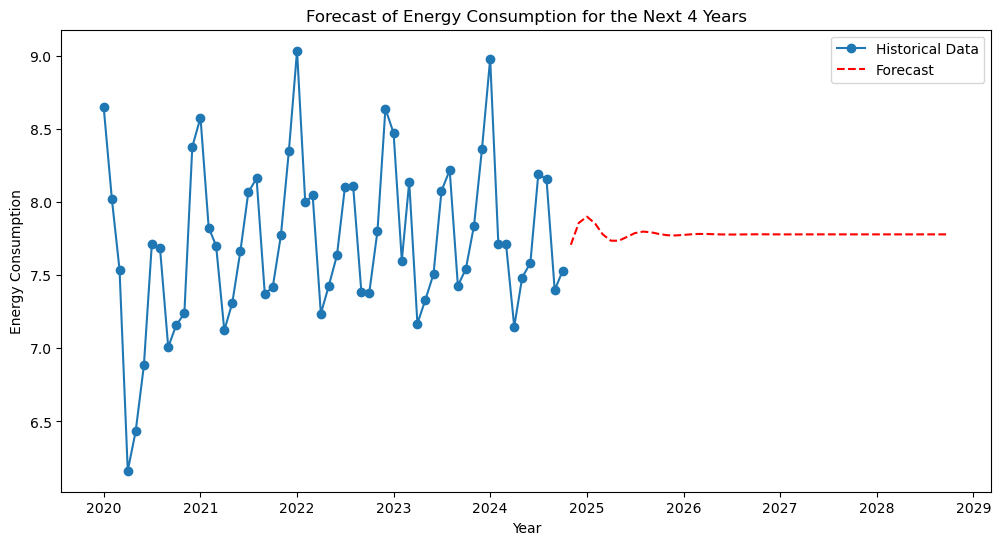

                Month  Forecasted_Energy_Consumption
2024-11-01 2024-11-01                       7.708506
2024-12-01 2024-12-01                       7.858275
2025-01-01 2025-01-01                       7.900716
2025-02-01 2025-02-01                       7.853324
2025-03-01 2025-03-01                       7.780654
2025-04-01 2025-04-01                       7.736589
2025-05-01 2025-05-01                       7.736183
2025-06-01 2025-06-01                       7.762172
2025-07-01 2025-07-01                       7.788326
2025-08-01 2025-08-01                       7.798834
2025-09-01 2025-09-01                       7.793646
2025-10-01 2025-10-01                       7.782179
2025-11-01 2025-11-01                       7.773854
2025-12-01 2025-12-01                       7.772423
2026-01-01 2026-01-01                       7.775982
2026-02-01 2026-02-01                       7.780388
2026-03-01 2026-03-01                       7.782649
2026-04-01 2026-04-01                       7.

In [244]:
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

model = ARIMA(df["Total Primary Energy Consumption"], order=(2,1,2))  # Adjust order as needed
model_fit = model.fit()

# Forecast for the next 48 months (4 years)
forecast_steps = 48
forecast = model_fit.forecast(steps=forecast_steps)

# Create future date range
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Total Primary Energy Consumption"], label="Historical Data", marker='o')
plt.plot(future_dates, forecast, label="Forecast", linestyle='dashed', color='red')
plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.title("Forecast of Energy Consumption for the Next 4 Years")
plt.legend()
plt.show()

# Print forecasted values
forecast_df = pd.DataFrame({"Month": future_dates, "Forecasted_Energy_Consumption": forecast})
print(forecast_df)

In [212]:
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=False)

model = ARIMA(df["Total Primary Energy Production"], order=(2,1,2))  # Adjust order as needed
model_fit = model.fit()

# Forecast for the next 48 months (4 years)
forecast_steps = 48
forecast = model_fit.forecast(steps=forecast_steps)

# Create future date range
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Total Primary Energy Production"], label="Historical Data", marker='o')
plt.plot(future_dates, forecast, label="Forecast", linestyle='dashed', color='red')
plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.title("Forecast of Energy Production for the Next 4 Years")
plt.legend()
plt.show()

# Print forecasted values
forecast_df = pd.DataFrame({"Month": future_dates, "Forecasted_Energy_Production": forecast})
print(forecast_df)

KeyError: 'Month'

In [202]:
forecast_df.to_csv("forecasted_energy_data.csv", index = False)